# Optional Logistic Regression Baseline

This optional notebook trains Logistic Regression on aggregated MFCC features. Logistic Regression is used instead of Linear Regression because this is a binary classification task.


## 1. Environment Setup

Run this notebook from a clean Google Colab session or locally.


## 2. Package Installation


This cell checks whether the libraries required by the logistic-regression workflow are installed and installs only the missing packages before the remaining audio-processing, analysis, plotting, and modelling steps run.

In [ ]:
# Purpose: Checks whether the libraries required by the logistic-regression workflow are
# installed and installs only the missing packages before the remaining audio-processing,
# analysis, plotting, and modelling steps run.
import importlib.util
import subprocess
import sys

# List the import names and their corresponding installable package names.
required_packages = [
    ("librosa", "librosa"),
    ("soundfile", "soundfile"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("joblib", "joblib"),
]

# Install only dependencies that are not already available in the active kernel.
missing = [pip_name for import_name, pip_name in required_packages if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages are already installed.")


Required packages are already installed.


## 3. Imports


This cell imports the standard-library and third-party tools used by the logistic-regression workflow and provides a print-based fallback when the richer notebook display function is unavailable.

In [ ]:
# Purpose: Imports the standard-library and third-party tools used by the logistic-regression
# workflow and provides a print-based fallback when the richer notebook display function is
# unavailable.
import json
import os
import random
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = print


## 4. Configuration and Random Seeds


This cell fixes the available random seeds for reproducibility and defines the shared audio, MFCC, class, sampling, and logistic-regression training settings used later in the notebook.

In [ ]:
# Purpose: Fixes the available random seeds for reproducibility and defines the shared audio,
# MFCC, class, sampling, and logistic-regression training settings used later in the notebook.
# Use a fixed seed so sampling, splitting, and model initialisation can be repeated.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# Configure the fixed audio representation and MFCC analysis window.
SAMPLE_RATE = 22050
FIXED_DURATION_SECONDS = 5.0
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = int(round(SAMPLE_RATE * 0.010))
WIN_LENGTH = int(round(SAMPLE_RATE * 0.025))

AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}
CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}

# Keep dataset and training limits together so quick runs are easy to configure.
MAX_FILES_PER_CLASS = None  # Set to a small number, such as 40, for a quick check.


## 5. Dataset Paths


This cell defines and calls a portable helper that mounts Google Drive when Colab is available and otherwise continues without failing in a local environment.

In [ ]:
# Purpose: Defines and calls a portable helper that mounts Google Drive when Colab is available
# and otherwise continues without failing in a local environment.
# Mount Google Drive when the notebook is running in Colab.
def mount_drive_if_colab(mount_point="/content/drive"):
    try:
        from google.colab import drive
        drive.mount(mount_point)
    except Exception:
        print("Not running in Colab, or Google Drive is already available.")

mount_drive_if_colab()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This cell defines the synthetic and bona-fide dataset paths, creates the output folders required by the logistic-regression workflow, and prints the active locations for confirmation.

In [ ]:
# Purpose: Defines the synthetic and bona-fide dataset paths, creates the output folders
# required by the logistic-regression workflow, and prints the active locations for
# confirmation.
# Change these paths to match your Google Drive dataset folders.
# Set the shared root used to locate the two audio classes.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")
SYNTHETIC_AUDIO_DIR = PROJECT_ROOT / "Datasets" / "MLAAD_10pct"
BONA_FIDE_AUDIO_DIR = PROJECT_ROOT / "Datasets" / "M_AILABS_bona_fide_subset"

# Build a model-specific output hierarchy under the project root.
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "logistic_regression"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"

# Create every output directory before any files are saved.
for directory in [OUTPUT_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Synthetic audio directory:", SYNTHETIC_AUDIO_DIR)
print("Bona-fide audio directory:", BONA_FIDE_AUDIO_DIR)
print("Output directory:", OUTPUT_DIR)


Synthetic audio directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/Datasets/MLAAD_10pct
Bona-fide audio directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/Datasets/M_AILABS_bona_fide_subset
Output directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/logistic_regression


## 6. Dataset Loading / Audio File Scan


This cell defines a recursive scanner that validates a dataset folder and records each supported audio file's path, class label, inferred language, and size in a Pandas table.

In [ ]:
# Purpose: Defines a recursive scanner that validates a dataset folder and records each
# supported audio file's path, class label, inferred language, and size in a Pandas table.
# Convert the supported files under one class directory into manifest rows.
def scan_audio_files(root_dir, label, class_name):
    root_dir = Path(root_dir)
    if not root_dir.exists():
        raise FileNotFoundError(f"Folder not found: {root_dir}")

    rows = []
    for path in sorted(root_dir.rglob("*")):
        if path.is_file() and path.suffix.lower() in AUDIO_EXTENSIONS:
            rows.append({
                "path": str(path),
                "relative_path": str(path.relative_to(root_dir)),
                "label": label,
                "class_name": class_name,
                "language": path.parent.name,
                "file_size_mb": path.stat().st_size / (1024 * 1024),
            })
    return pd.DataFrame(rows)


This cell scans both class directories, optionally limits each class for a quick run, combines and reproducibly shuffles the records into one manifest, and displays a short preview.

In [ ]:
# Purpose: Scans both class directories, optionally limits each class for a quick run, combines
# and reproducibly shuffles the records into one manifest, and displays a short preview.
# Scan the synthetic and bona-fide directories separately with their correct labels.
synthetic_manifest = scan_audio_files(SYNTHETIC_AUDIO_DIR, label=1, class_name=CLASS_NAMES[1])
bona_fide_manifest = scan_audio_files(BONA_FIDE_AUDIO_DIR, label=0, class_name=CLASS_NAMES[0])

# Optionally draw a reproducible smaller sample for a quick test run.
if MAX_FILES_PER_CLASS:
    synthetic_manifest = synthetic_manifest.sample(min(MAX_FILES_PER_CLASS, len(synthetic_manifest)), random_state=RANDOM_STATE)
    bona_fide_manifest = bona_fide_manifest.sample(min(MAX_FILES_PER_CLASS, len(bona_fide_manifest)), random_state=RANDOM_STATE)

# Merge both classes into one shuffled manifest for later splitting.
manifest = pd.concat([bona_fide_manifest, synthetic_manifest], ignore_index=True)
manifest = manifest.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("Total files:", len(manifest))
display(manifest.head())


Total files: 12944


,path,relative_path,label,class_name,language,file_size_mb
0,/content/drive/MyDrive/Colab Notebooks/Educati...,fake/en/Llasa-1B-Multilingual/pink_fairy_book_...,1,synthetic,Llasa-1B-Multilingual,0.368462
1,/content/drive/MyDrive/Colab Notebooks/Educati...,fake/de/Chatterbox Multilingual/altehaus_009_1...,1,synthetic,Chatterbox Multilingual,0.415565
2,/content/drive/MyDrive/Colab Notebooks/Educati...,fake/en/Metavoice-1B/northandsouth_38_f000272.wav,1,synthetic,Metavoice-1B,0.055557
3,/content/drive/MyDrive/Colab Notebooks/Educati...,en/en/northandsouth_05_f000169.wav,0,bona_fide,en,0.130991
4,/content/drive/MyDrive/Colab Notebooks/Educati...,en/en/poisoned_pen_08_f000016.wav,0,bona_fide,en,0.302805


## 7. Dataset Inspection


This cell summarises the manifest by class and language and displays the overall class counts together with the 20 most frequent class-language combinations.

In [ ]:
# Purpose: Summarises the manifest by class and language and displays the overall class counts
# together with the 20 most frequent class-language combinations.
# Count recordings by class and by class-language combination.
class_summary = manifest.groupby(["label", "class_name"]).size().reset_index(name="files")
language_summary = manifest.groupby(["class_name", "language"]).size().reset_index(name="files")

display(class_summary)
display(language_summary.sort_values("files", ascending=False).head(20))


,label,class_name,files
0,0,bona_fide,3997
1,1,synthetic,8947


,class_name,language,files
1,bona_fide,en,3282
0,bona_fide,de,715
6,synthetic,Edge-TTS,407
43,synthetic,OmniVoice,402
55,synthetic,VoxCPM2,295
9,synthetic,Fish-S2-Pro,288
56,synthetic,Voxtral,283
18,synthetic,KugelAudio,214
20,synthetic,LEMAS-TTS,195
15,synthetic,Kani-TTS-370M,191


## 8. Data Quality Checks


This cell measures missing paths, files absent from disk, duplicate paths, and represented classes, then stops the workflow if both labels are not present or duplicate recordings could compromise the experiment.

In [ ]:
# Purpose: Measures missing paths, files absent from disk, duplicate paths, and represented
# classes, then stops the workflow if both labels are not present or duplicate recordings could
# compromise the experiment.
# Calculate manifest checks before any expensive audio processing begins.
quality_checks = pd.DataFrame([
    {"check": "missing_paths", "value": int(manifest["path"].isna().sum())},
    {"check": "missing_files", "value": int((~manifest["path"].map(lambda p: Path(p).exists())).sum())},
    {"check": "duplicate_paths", "value": int(manifest["path"].duplicated().sum())},
    {"check": "classes_present", "value": ", ".join(map(str, sorted(manifest["label"].unique())))},
])

display(quality_checks)

# Stop early if the manifest does not contain both required target classes.
if set(manifest["label"].unique()) != {0, 1}:
    raise ValueError("Both classes are required: 0=bona-fide and 1=synthetic/deepfake.")
if manifest["path"].duplicated().any():
    raise ValueError("Duplicate audio paths were found. Remove duplicates before training.")


,check,value
0,missing_paths,0
1,missing_files,0
2,duplicate_paths,0
3,classes_present,"0, 1"


## 9. Audio Preprocessing

Audio is loaded as mono, resampled, padded or truncated, and normalised.


## 10. MFCC Feature Extraction


This cell defines the audio preprocessing and MFCC extraction functions and reduces each time-varying MFCC matrix to a fixed feature vector containing the mean and standard deviation of every coefficient.

In [ ]:
# Purpose: Defines the audio preprocessing and MFCC extraction functions and reduces each
# time-varying MFCC matrix to a fixed feature vector containing the mean and standard deviation
# of every coefficient.
# Resample, pad or truncate, and peak-normalise every waveform consistently.
def load_audio_fixed(path):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    target_length = int(SAMPLE_RATE * FIXED_DURATION_SECONDS)

    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak

    return audio.astype(np.float32)


# Transform the standardised waveform into the MFCC representation required downstream.
def extract_mfcc_features(path):
    audio = load_audio_fixed(path)
    return librosa.feature.mfcc(
        y=audio,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
    ).astype(np.float32)


# Summarise each coefficient over time to create one fixed-length feature vector.
def aggregate_mfcc(mfcc):
    means = mfcc.mean(axis=1)
    stds = mfcc.std(axis=1)
    return np.concatenate([means, stds]).astype(np.float32)


## 11. Label Preparation


This cell states the binary label mapping and displays the number of bona-fide and synthetic recordings so the target variable can be checked before splitting and modelling.

In [ ]:
# Purpose: States the binary label mapping and displays the number of bona-fide and synthetic
# recordings so the target variable can be checked before splitting and modelling.
print("Label meaning: 0 = bona-fide, 1 = synthetic/deepfake")
display(manifest["label"].value_counts().sort_index().rename(index=CLASS_NAMES).to_frame("files"))


Label meaning: 0 = bona-fide, 1 = synthetic/deepfake


,files
label,
bona_fide,3997
synthetic,8947


## 12. Train / Validation / Test Split


This cell creates reproducible stratified training, validation, and test partitions in a 70:15:15 ratio, resets their row indexes, and displays the size and class balance of each split.

In [ ]:
# Purpose: Creates reproducible stratified training, validation, and test partitions in a
# 70:15:15 ratio, resets their row indexes, and displays the size and class balance of each
# split.
# Reserve 30 percent of the manifest before dividing it equally into validation and test data.
train_df, temp_df = train_test_split(
    manifest,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=manifest["label"],
)

# Split the held-out portion equally while preserving the class distribution.
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "bona_fide": [int((train_df["label"] == 0).sum()), int((validation_df["label"] == 0).sum()), int((test_df["label"] == 0).sum())],
    "synthetic": [int((train_df["label"] == 1).sum()), int((validation_df["label"] == 1).sum()), int((test_df["label"] == 1).sum())],
})
display(split_summary)


,split,rows,bona_fide,synthetic
0,train,9060,2798,6262
1,validation,1942,599,1343
2,test,1942,600,1342


## 13. Aggregated MFCC Feature Preparation


This cell extracts one aggregated MFCC vector per readable file, keeps its label and metadata aligned, reports any skipped recordings, and builds the training and validation feature tables.

In [ ]:
# Purpose: Extracts one aggregated MFCC vector per readable file, keeps its label and metadata
# aligned, reports any skipped recordings, and builds the training and validation feature
# tables.
# Convert a manifest split into aligned model inputs, labels, and retained metadata.
def build_feature_table(df, split_name):
    features = []
    labels = []
    kept_rows = []

    for _, row in df.iterrows():
        try:
            mfcc = extract_mfcc_features(row["path"])
            features.append(aggregate_mfcc(mfcc))
            labels.append(int(row["label"]))
            kept_rows.append(row)
        except Exception as exc:
            print(f"Skipping {row['path']}: {exc}")

    X = np.vstack(features).astype(np.float32)
    y = np.array(labels, dtype=np.int64)
    meta = pd.DataFrame(kept_rows).reset_index(drop=True)
    print(f"{split_name}: {X.shape[0]} files, {X.shape[1]} features")
    return X, y, meta

X_train, y_train, train_meta = build_feature_table(train_df, "train")
X_validation, y_validation, validation_meta = build_feature_table(validation_df, "validation")


train: 9060 files, 80 features
validation: 1942 files, 80 features


## 14. Train-only Scaling


This cell fits a standard scaler using only the training feature vectors, applies the learned transformation to the validation vectors, and reports the resulting matrix dimensions.

In [ ]:
# Purpose: Fits a standard scaler using only the training feature vectors, applies the learned
# transformation to the validation vectors, and reports the resulting matrix dimensions.
# Fit feature scaling only on training data to prevent information leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_validation_scaled = scaler.transform(X_validation).astype(np.float32)

print("Scaler fitted on training data only.")
print("Train feature shape:", X_train_scaled.shape)
print("Validation feature shape:", X_validation_scaled.shape)


Scaler fitted on training data only.
Train feature shape: (9060, 80)
Validation feature shape: (1942, 80)


## 15. Logistic Regression Model Definition


This cell creates and prints an example balanced logistic-regression classifier, showing the main configuration that will be varied during validation experiments.

In [ ]:
# Purpose: Creates and prints an example balanced logistic-regression classifier, showing the
# main configuration that will be varied during validation experiments.
from sklearn.linear_model import LogisticRegression

# Construct a representative estimator so its architecture or configuration can be inspected.
example_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
print(example_model)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


## 16. Validation Hyperparameter Experiments


This cell fits balanced logistic-regression candidates with different regularisation strengths, compares their validation metrics, ranks them by F1 score, and retains the best-performing estimator.

In [ ]:
# Purpose: Fits balanced logistic-regression candidates with different regularisation strengths,
# compares their validation metrics, ranks them by F1 score, and retains the best-performing
# estimator.
from sklearn.linear_model import LogisticRegression

# Define the candidate configurations that will be compared on validation data.
experiments = [
    {"name": "logistic_c_1", "C": 1.0, "penalty": "l2"},
    {"name": "logistic_c_01", "C": 0.1, "penalty": "l2"},
    {"name": "logistic_c_10", "C": 10.0, "penalty": "l2"},
]

validation_results = []
models = {}

# Train and evaluate each candidate without using the test split for selection.
for experiment in experiments:
    model = LogisticRegression(
        C=experiment["C"],
        penalty=experiment["penalty"],
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)

    validation_probability = model.predict_proba(X_validation_scaled)[:, 1]
    validation_pred = (validation_probability >= 0.5).astype(int)

    validation_results.append({
        "model": "Logistic Regression",
        "variant": experiment["name"],
        "C": experiment["C"],
        "penalty": experiment["penalty"],
        "accuracy": accuracy_score(y_validation, validation_pred),
        "precision": precision_score(y_validation, validation_pred, zero_division=0),
        "recall": recall_score(y_validation, validation_pred, zero_division=0),
        "f1": f1_score(y_validation, validation_pred, zero_division=0),
    })
    models[experiment["name"]] = model

# Rank candidate models by validation F1 score before selecting the winner.
validation_results_df = pd.DataFrame(validation_results).sort_values("f1", ascending=False)
display(validation_results_df)

best_variant = validation_results_df.iloc[0]["variant"]
best_model = models[best_variant]
print("Selected from validation data:", best_variant)


,model,variant,C,penalty,accuracy,precision,recall,f1
2,Logistic Regression,logistic_c_10,10.0,l2,0.938723,0.990385,0.920328,0.954072
0,Logistic Regression,logistic_c_1,1.0,l2,0.928424,0.988636,0.906925,0.946019
1,Logistic Regression,logistic_c_01,0.1,l2,0.914521,0.985962,0.889054,0.935004


Selected from validation data: logistic_c_10


## 17. Final Test Evaluation


This cell processes the untouched test split only after selecting the logistic-regression variant, generates binary predictions, calculates the final accuracy, precision, recall, and F1 score, and displays the results.

In [ ]:
# Purpose: Processes the untouched test split only after selecting the logistic-regression
# variant, generates binary predictions, calculates the final accuracy, precision, recall, and
# F1 score, and displays the results.
# The test split is processed only after choosing the model from validation results.
# Build the untouched test inputs only after validation-based model selection is complete.
X_test, y_test, test_meta = build_feature_table(test_df, "test")
X_test_scaled = scaler.transform(X_test).astype(np.float32)

# Convert the selected model's outputs into positive-class probabilities.
test_probability = best_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_probability >= 0.5).astype(int)

# Calculate the final held-out classification metrics from thresholded predictions.
test_results_df = pd.DataFrame([{
    "selected_variant": best_variant,
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
}])

display(test_results_df)


test: 1942 files, 80 features


,selected_variant,accuracy,precision,recall,f1
0,logistic_c_10,0.946962,0.989723,0.932936,0.960491


## 18. Additional Subgroup / Multilingual Analysis


This cell joins the final predictions to the test metadata and calculates language-specific performance for subgroups containing at least five recordings, avoiding unstable summaries for very small groups.

In [ ]:
# Purpose: Joins the final predictions to the test metadata and calculates language-specific
# performance for subgroups containing at least five recordings, avoiding unstable summaries for
# very small groups.
# Prepare language-level metrics using the final test predictions.
subgroup_rows = []
subgroup_df = test_meta.copy().reset_index(drop=True)
subgroup_df["y_true"] = y_test
subgroup_df["y_pred"] = test_pred

# Skip very small language groups and score those with enough test examples.
for language, group in subgroup_df.groupby("language"):
    if len(group) < 5:
        continue
    subgroup_rows.append({
        "language": language,
        "files": len(group),
        "accuracy": accuracy_score(group["y_true"], group["y_pred"]),
        "precision": precision_score(group["y_true"], group["y_pred"], zero_division=0),
        "recall": recall_score(group["y_true"], group["y_pred"], zero_division=0),
        "f1": f1_score(group["y_true"], group["y_pred"], zero_division=0),
    })

subgroup_results_df = pd.DataFrame(subgroup_rows)
if subgroup_results_df.empty:
    print("No language subgroup has at least 5 test files.")
else:
    display(subgroup_results_df.sort_values("f1", ascending=False))


,language,files,accuracy,precision,recall,f1
0,CaroTTS,19,1.000000,1.0,1.000000,1.000
1,Cartesia.ai (Sonic-3),10,1.000000,1.0,1.000000,1.000
2,Chatterbox Multilingual,13,1.000000,1.0,1.000000,1.000
4,Edge-TTS,58,1.000000,1.0,1.000000,1.000
6,ElevenLabs-v3,19,1.000000,1.0,1.000000,1.000
...,...,...,...,...,...,...
49,VoxCPM-0.5B,13,0.230769,1.0,0.230769,0.375
42,OpenVoiceV2,7,0.142857,1.0,0.142857,0.250
24,LongCat-AudioDiT,15,0.066667,1.0,0.066667,0.125
57,de,111,0.918919,0.0,0.000000,0.000


## 19. Confusion Matrix and Saved Outputs


This cell saves the logistic-regression validation and test results, language metrics when available, confusion-matrix data and figures, preprocessing state, and selected model, then prints the main artifact paths.

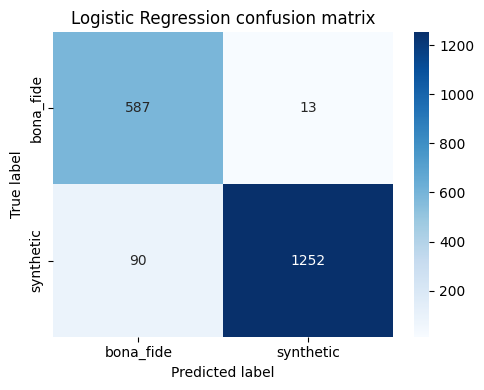

Saved validation results: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/logistic_regression/tables/logistic_regression_validation_experiments.csv
Saved test metrics: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/logistic_regression/metrics/logistic_regression_test_metrics.json
Saved confusion matrix: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/logistic_regression/metrics/logistic_regression_confusion_matrix.csv
Saved scaler: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/logistic_regression/models/logistic_regression_standard_scaler.joblib
Saved model: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/logistic_regression/models/logistic_regression_best_model.joblib


In [ ]:
# Purpose: Saves the logistic-regression validation and test results, language metrics when
# available, confusion-matrix data and figures, preprocessing state, and selected model, then
# prints the main artifact paths.
# Define consistent destinations for evaluation, plots, preprocessing state, and models.
validation_results_path = TABLES_DIR / "logistic_regression_validation_experiments.csv"
test_metrics_path = METRICS_DIR / "logistic_regression_test_metrics.json"
confusion_matrix_path = METRICS_DIR / "logistic_regression_confusion_matrix.csv"
subgroup_metrics_path = METRICS_DIR / "logistic_regression_language_subgroup_metrics.csv"
confusion_plot_path = FIGURES_DIR / "logistic_regression_confusion_matrix.png"
scaler_path = MODELS_DIR / "logistic_regression_standard_scaler.joblib"
model_path = MODELS_DIR / "logistic_regression_best_model.joblib"

validation_results_df.to_csv(validation_results_path, index=False)
with open(test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(test_results_df.iloc[0].to_dict(), f, indent=2)

# Build a labelled confusion matrix from the final test predictions.
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
pd.DataFrame(cm, index=[CLASS_NAMES[0], CLASS_NAMES[1]], columns=[CLASS_NAMES[0], CLASS_NAMES[1]]).to_csv(confusion_matrix_path)
if not subgroup_results_df.empty:
    subgroup_results_df.to_csv(subgroup_metrics_path, index=False)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Logistic Regression confusion matrix")
plt.tight_layout()
plt.savefig(confusion_plot_path, dpi=300, bbox_inches="tight")
plt.show()

joblib.dump(scaler, scaler_path)
joblib.dump(best_model, model_path)


print("Saved validation results:", validation_results_path)
print("Saved test metrics:", test_metrics_path)
print("Saved confusion matrix:", confusion_matrix_path)
print("Saved scaler:", scaler_path)
print("Saved model:", model_path)


## 20. Reproducibility Checks


This cell displays a compact reproducibility record for the logistic-regression workflow, including the stratified split, train-only preprocessing, test-set isolation, label mapping, dependency design, and random seed.

In [ ]:
# Purpose: Displays a compact reproducibility record for the logistic-regression workflow,
# including the stratified split, train-only preprocessing, test-set isolation, label mapping,
# dependency design, and random seed.
# Collect the main reproducibility and leakage-prevention properties for display.
checks = {
    "self_contained": True,
    "external_helper_file_required": False,
    "custom_helper_imports": False,
    "split": "70/15/15 stratified by class label",
    "scaler_fitted_on": "training split only",
    "test_used_for_model_selection": False,
    "label_mapping": CLASS_NAMES,
    "random_state": RANDOM_STATE,
}

display(pd.DataFrame(list(checks.items()), columns=["check", "value"]))


,check,value
0,self_contained,True
1,external_helper_file_required,False
2,custom_helper_imports,False
3,split,70/15/15 stratified by class label
4,scaler_fitted_on,training split only
5,test_used_for_model_selection,False
6,label_mapping,"{0: 'bona_fide', 1: 'synthetic'}"
7,random_state,42
